In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
identifier = "short_name"
target = "preferred_foot"
features = [
    "age", "height_cm", "weight_kg",
    "pace", "shooting", "passing", "dribbling", "defending", "physic",
    "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy",
    "attacking_short_passing", "attacking_volleys",
    "skill_dribbling", "skill_curve", "skill_long_passing", "skill_ball_control",
    "movement_acceleration", "movement_sprint_speed", "movement_agility",
    "movement_reactions", "movement_balance",
    "power_shot_power", "power_jumping", "power_stamina", "power_strength",
    "mentality_aggression", "mentality_positioning", "mentality_vision",
    "defending_standing_tackle",
    "goalkeeping_diving", "goalkeeping_reflexes"
]

df = pd.read_csv("data_fifa20/players_20.csv", usecols=[identifier, target] + features, low_memory=False)
df = df.dropna(subset=[target]).copy().reset_index(drop=True)

imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

le = LabelEncoder()
y = le.fit_transform(df[target])
X = df[features].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Classes: {le.classes_}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Classes: ['Left' 'Right']
Train: (14786, 33) | Test: (3697, 33)


In [3]:
# Test different depths
depths = [3, 5, 10, 15, None]
results_depth = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    results_depth.append({"Max Depth": str(d), "Accuracy (%)": round(acc * 100, 2)})
    print(f"Depth {str(d):5} → Accuracy: {acc:.4f}")

df_depth = pd.DataFrame(results_depth)
print("\n", df_depth)

Depth 3     → Accuracy: 0.7660
Depth 5     → Accuracy: 0.7709
Depth 10    → Accuracy: 0.7409
Depth 15    → Accuracy: 0.7090
Depth None  → Accuracy: 0.6692

   Max Depth  Accuracy (%)
0         3         76.60
1         5         77.09
2        10         74.09
3        15         70.90
4      None         66.92


In [7]:
# Best model + Classification Report
best_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)

print(" Classification Report ")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Recalling
sample = X_test[0].reshape(1, -1)
prediction = le.inverse_transform(best_dt.predict(sample))
print(f"Recalling example → Predicted foot: {prediction[0]}")
print(f"Actual foot:         {le.inverse_transform([y_test[0]])[0]}")

 Classification Report 
              precision    recall  f1-score   support

        Left       0.41      0.26      0.32       865
       Right       0.80      0.89      0.84      2832

    accuracy                           0.74      3697
   macro avg       0.60      0.57      0.58      3697
weighted avg       0.71      0.74      0.72      3697

Recalling example → Predicted foot: Right
Actual foot:         Left


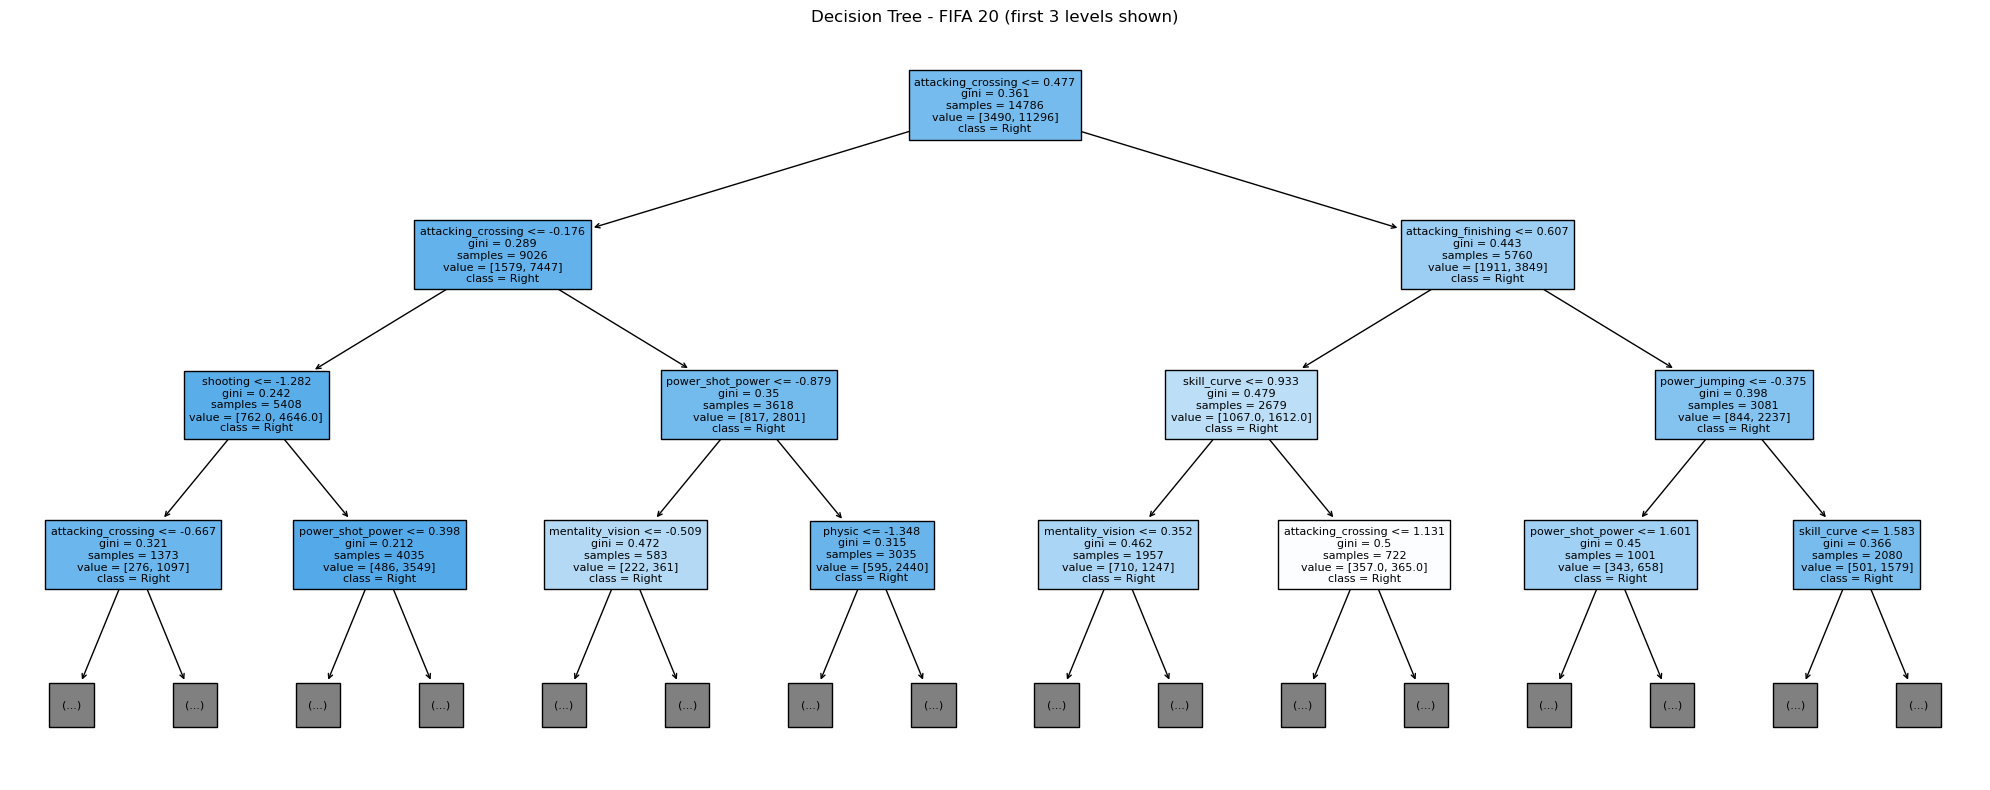

In [5]:
# Visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=features, class_names=le.classes_,
          filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree - FIFA 20 (first 3 levels shown)")
plt.tight_layout()
plt.show()

                      Model  Accuracy (%)
0             BPN (LR=0.05)         76.95
1  Decision Tree (depth=10)         74.09


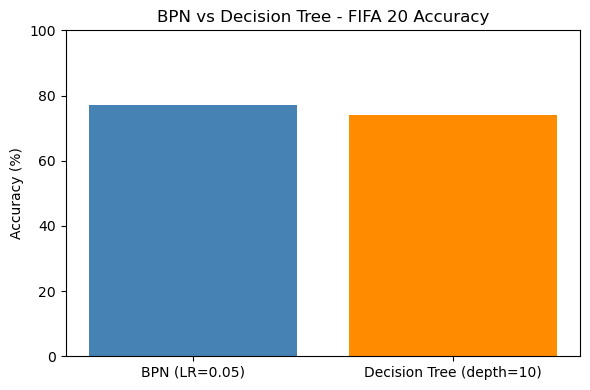

In [6]:
# BPN vs Decision Tree comparison
bpn_acc = 0.7695  # Best BPN: LR 0.05
dt_acc = accuracy_score(y_test, y_pred)

comparison = pd.DataFrame({
    "Model": ["BPN (LR=0.05)", "Decision Tree (depth=10)"],
    "Accuracy (%)": [round(bpn_acc * 100, 2), round(dt_acc * 100, 2)]
})
print(comparison)

plt.figure(figsize=(6, 4))
plt.bar(comparison["Model"], comparison["Accuracy (%)"], color=["steelblue", "darkorange"])
plt.title("BPN vs Decision Tree - FIFA 20 Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()